# SmartHeart Colab Training

## 1. Clone the repository

Clone the latest `main` branch into the Colab workspace. If it is already present, update it with a fast-forward pull, then make it the active working directory.

In [15]:
!if [ -d /content/smart-heart/.git ]; then git -C /content/smart-heart pull --ff-only origin main; else git clone --branch main --single-branch https://github.com/Bojan-Ivanovski/smart-heart.git /content/smart-heart; fi
%cd /content/smart-heart


remote: Enumerating objects: 22, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 15 (delta 11), reused 12 (delta 9), pack-reused 0 (from 0)
Unpacking objects: 100% (15/15), 52.37 KiB | 1.75 MiB/s, done.
From https://github.com/Bojan-Ivanovski/smart-heart
 * branch            main       -> FETCH_HEAD
   c8b53de..53d633e  main       -> origin/main
Updating c8b53de..53d633e
Fast-forward
 SmartHeart_Colab.ipynb  | 4424 ++++++++++++++++++++++++++++++++++++++++++++---
 src/curriculum/base.py  |   40 +-
 src/training/trainer.py |   29 +-
 3 files changed, 4259 insertions(+), 234 deletions(-)
/content/smart-heart


## 2. Configure the run

Select an **A100 GPU** from **Runtime > Change runtime type** for the quality-focused configuration below. The 1B Gemma model, SP architecture, LoRA, and cognitive-function source provide a practical full-curriculum run. Window sizes are configured per stage because samples expand from individual windows to recordings and complete patients. Evaluation automatically reuses the exact size configured for each training stage. Use `cuda` for an A100 or L4, `xla` for TPU, or `cpu` only for functional checks.

In [28]:
import os

DEVICE = "cuda"  # @param ["cuda", "xla", "cpu"]
DATASET = "adhd_cognitive_function"  # @param ["adhd_cognitive_function", "adhd_children", "adhd_gameplay", "all"]
MODEL_ID = "google/gemma-3-1b-pt"  # @param {type:"string"}
STAGE_1_WINDOW_SIZE = 4096  # @param {type:"integer"}
STAGE_2_WINDOW_SIZE = 4096  # @param {type:"integer"}
STAGE_3_WINDOW_SIZE = 2048  # @param {type:"integer"}
STAGE_4_WINDOW_SIZE = 2048  # @param {type:"integer"}
STAGE_5_WINDOW_SIZE = 128  # @param {type:"integer"}
STAGE_WINDOW_SIZES = {
    "stage1_mcq": STAGE_1_WINDOW_SIZE,
    "stage2_eeg_captioning": STAGE_2_WINDOW_SIZE,
    "stage3_attention_task_cot": STAGE_3_WINDOW_SIZE,
    "stage4_resting_state_cot": STAGE_4_WINDOW_SIZE,
    "stage5_diagnostic_cot": STAGE_5_WINDOW_SIZE,
}
PREVIEW_WINDOW_SIZE = STAGE_WINDOW_SIZES["stage1_mcq"]
SEED = 42  # @param {type:"integer"}
FRESH_START = False  # @param {type:"boolean"}

os.environ["SMARTHEART_DEVICE"] = DEVICE
os.environ["SMARTHEART_DATASET"] = DATASET
os.environ["SMARTHEART_MODEL_ID"] = MODEL_ID
os.environ["SMARTHEART_WINDOW_SIZE"] = str(PREVIEW_WINDOW_SIZE)
os.environ["SMARTHEART_SEED"] = str(SEED)
os.environ["SMARTHEART_FRESH_START"] = "1" if FRESH_START else "0"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
print(f"device={DEVICE}, dataset={DATASET}, model={MODEL_ID}")
print(f"stage_window_sizes={STAGE_WINDOW_SIZES}")


device=cuda, dataset=adhd_cognitive_function, model=google/gemma-3-1b-pt, window_size=128


## 3. Install dependencies

Upgrade `pip`, remove Colab's unused `diffusers` and `gradio` packages that conflict with OpenTSLM's Hugging Face stack, and install the repository's pinned environment. CUDA and CPU runs use the base requirements; XLA runs additionally install the TPU runtime and its official wheel source.

In [ ]:
%%bash
set -euo pipefail
python -m pip install --upgrade pip
python -m pip uninstall --yes diffusers gradio
if [[ "${SMARTHEART_DEVICE}" == "xla" ]]; then
    python -m pip install -r requirements-tpu.txt
else
    python -m pip install -r requirements.txt
fi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 51.0 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Found existing installation: diffusers 0.40.0
Uninstalling diffusers-0.40.0:
  Successfully uninstalled diffusers-0.40.0
Found existing installation: gradio 6.26.0
Uninstalling gradio-6.26.0:
  Successfully uninstalled gradio-6.26.0
  Cloning https://github.com/StanfordBDHG/OpenTSLM.git (to revision refs/pull/47/head) to /tmp/pip-install-pn9crqe4/opentslm_bdc62bb0a1a9421db77aeac3f364273e
  Did not find branch or tag 'refs/pull/47/head', assuming revision or ref.
  Resolved https://github.com/StanfordBDHG/OpenTSLM.git to commit 3356bbd4ecd2a88f713784d3e14f71a2b5b5b2f2
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with stat

  Running command git clone --filter=blob:none --quiet https://github.com/StanfordBDHG/OpenTSLM.git /tmp/pip-install-pn9crqe4/opentslm_bdc62bb0a1a9421db77aeac3f364273e
  Running command git fetch -q https://github.com/StanfordBDHG/OpenTSLM.git refs/pull/47/head
  Running command git checkout -q 3356bbd4ecd2a88f713784d3e14f71a2b5b5b2f2


## 4. Validate the dataset

Verify the canonical dataset cloned with the repository and report its patient and signal-archive counts. No extraction or build step is required.

In [ ]:
%%bash
set -euo pipefail
test -d dataset/patients
echo "Patients: $(find dataset/patients -mindepth 1 -maxdepth 1 -type d | wc -l)"
echo "Signal archives: $(find dataset/patients -type f -name 'signals.npz' | wc -l)"


Patients: 210
Signal archives: 210


## 5. Validate the environment and preview data

Report the installed PyTorch version and CUDA availability, then preview the selected dataset to confirm discovery and loading before model training begins.

In [ ]:
!python -c "import torch; print('torch:', torch.__version__); print('cuda_available:', torch.cuda.is_available())"
!python -m src.main preview --source {DATASET} --window-size {PREVIEW_WINDOW_SIZE} --stage stage1_mcq


torch: 2.11.0+cu128
cuda_available: True
stage: stage1_mcq
stage_samples: 10252
signal_windows: 5126
patient: cognitive-function__fadhd__001
recordings: 01-eyes_open_baseline_cz_f4
segments: 01-eyes_open_baseline_cz_f4__segment-001
split: train
source: adhd_cognitive_function

PRE-PROMPT
Analyze the EEG time series and answer the multiple-choice question using the measured signal pattern.

TIME SERIES
[1] shape=(2048,) Recording 01-eyes_open_baseline_cz_f4, channel Cz, contains raw_eeg from the eyes_open_baseline_cz_f4 condition. Its original mean is -0.1836 and standard deviation is 23.9189.
[2] shape=(2048,) Recording 01-eyes_open_baseline_cz_f4, channel F4, contains raw_eeg from the eyes_open_baseline_cz_f4 condition. Its original mean is 0.5518 and standard deviation is 15.0422.

POST-PROMPT
Question: Among the listed options, which frequency band has the greatest relative power in this window?
A. Delta
B. Theta
C. Beta
D. Gamma
Answer with only A, B, C, or D.

REFERENCE ANALYSIS (

## 6. Authenticate with Hugging Face

Gemma access may require accepting its license on Hugging Face. Add a Colab secret named `HF_TOKEN` using the key icon in the left sidebar and grant this notebook access. The next cell stores it in Hugging Face's local cache without printing it.

In [ ]:
from google.colab import userdata
from huggingface_hub import login

try:
    hf_token = userdata.get("HF_TOKEN")
except Exception:
    hf_token = None

if hf_token:
    login(token=hf_token, add_to_git_credential=False)
    print("Hugging Face authentication configured.")
else:
    print("HF_TOKEN is not configured. Public models can still be downloaded.")


Hugging Face authentication configured.


## 7. Train the model

Train each curriculum stage separately with quality-oriented epochs, batch sizes, learning rates, and stage-aware window sizes. Earlier stages learn signal interpretation from abundant window examples; later stages combine multiple windows and therefore use bounded window sizes. Each command initializes from the preceding stage checkpoint. Set `FRESH_START` when restarting the complete curriculum. `FRESH_START` applies only to Stage 1, and LoRA remains enabled. The cell stops immediately if any stage fails.

In [29]:
import os
import subprocess
import sys

if DEVICE == "xla":
    os.environ["PJRT_DEVICE"] = "TPU"
os.environ["PYTHONUNBUFFERED"] = "1"

common_args = [
    sys.executable, "-u", "-m", "src.main", "train",
    "--model-id", MODEL_ID,
    "--architecture", "sp",
    "--source", DATASET,
    "--device", DEVICE,
    "--seed", str(SEED),
]
stages = [
    # ("Stage 1: MCQ warmup", "stage1_mcq", 4, 2, "5e-5"),
    # ("Stage 2: EEG captioning", "stage2_eeg_captioning", 2, 3, "5e-5"),
    # ("Stage 3: attention task reasoning", "stage3_attention_task_cot", 1, 8, "2e-5"),
    # ("Stage 4: resting-state reasoning", "stage4_resting_state_cot", 1, 4, "2e-5"),
    ("Stage 5: diagnostic reasoning", "stage5_diagnostic_cot", 1, 10, "1e-5"),
]

for stage_index, (label, stage, batch_size, epochs, learning_rate) in enumerate(stages):
    command = common_args + [
        "--stage", stage,
        "--window-size", str(STAGE_WINDOW_SIZES[stage]),
        "--batch-size", str(batch_size),
        "--epochs", str(epochs),
        "--learning-rate", learning_rate,
    ]
    if stage_index == 0 and FRESH_START:
        command.append("--fresh-start")
    print(
        f"[notebook] Starting {label} "
        f"with window_size={STAGE_WINDOW_SIZES[stage]}",
        flush=True,
    )
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="", flush=True)
    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, command)


[notebook] Starting Stage 5: diagnostic reasoning
[train] loading model=google/gemma-3-1b-pt runtime=cuda
2026-09-05 23:26:10.009786: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-05 23:26:10.080202: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disa

## 8. Inspect checkpoints

List every checkpoint artifact produced by training together with its allocated file size.

In [30]:
!find checkpoints -type f -printf '%p (%k KB)\n'


checkpoints/google__gemma-3-1b-pt__fa56a704/sp/stage3_attention_task_cot.pt (59956 KB)
checkpoints/google__gemma-3-1b-pt__fa56a704/sp/stage4_resting_state_cot.pt (59956 KB)
checkpoints/google__gemma-3-1b-pt__fa56a704/sp/stage5_diagnostic_cot.pt (59960 KB)
checkpoints/google__gemma-3-1b-pt__fa56a704/sp/stage1_mcq.pt (59948 KB)
checkpoints/google__gemma-3-1b-pt__fa56a704/sp/stage2_eeg_captioning.pt (59956 KB)


## 9. Validate and test the checkpoint

Load the curriculum checkpoints produced above and evaluate every stage on the held-out validation and test patient partitions. Each stage uses the same bounded window size as training. Output is streamed directly into Colab, and detailed predictions are written under `results/`.

In [ ]:
import subprocess
import sys

evaluation_groups = {}
for stage_name, window_size in STAGE_WINDOW_SIZES.items():
    evaluation_groups.setdefault(window_size, []).append(stage_name)

for split in ("validation", "test"):
    for window_size, stage_names in evaluation_groups.items():
        command = [
            sys.executable, "-u", "-m", "src.main", "evaluate",
            "--source", DATASET,
            "--device", DEVICE,
            "--model-id", MODEL_ID,
            "--split", split,
            "--batch-size", "1",
            "--window-size", str(window_size),
        ]
        for stage_name in stage_names:
            command.extend(["--stage", stage_name])
        print(
            f"[notebook] Evaluating split={split} "
            f"stages={','.join(stage_names)} window_size={window_size}",
            flush=True,
        )
        process = subprocess.Popen(
            command,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        assert process.stdout is not None
        for line in process.stdout:
            print(line, end="", flush=True)
        return_code = process.wait()
        if return_code != 0:
            raise subprocess.CalledProcessError(return_code, command)


## 10. Generate one prediction

Load the final diagnostic checkpoint and generate one response for a single held-out patient. The cell visualizes normalized model inputs, presents the prompt in labeled sections, and formats the generated response separately. Set `ADDITIONAL_INSTRUCTION` to refine the request without removing the patient's clinical context. This does not calculate metrics or process the rest of the test split.

### Patient input

**Patient:** `cognitive-function__fadhd__006`  
**Split:** `test`  
**Stage:** `stage5_diagnostic_cot`  
**Available series:** `38`

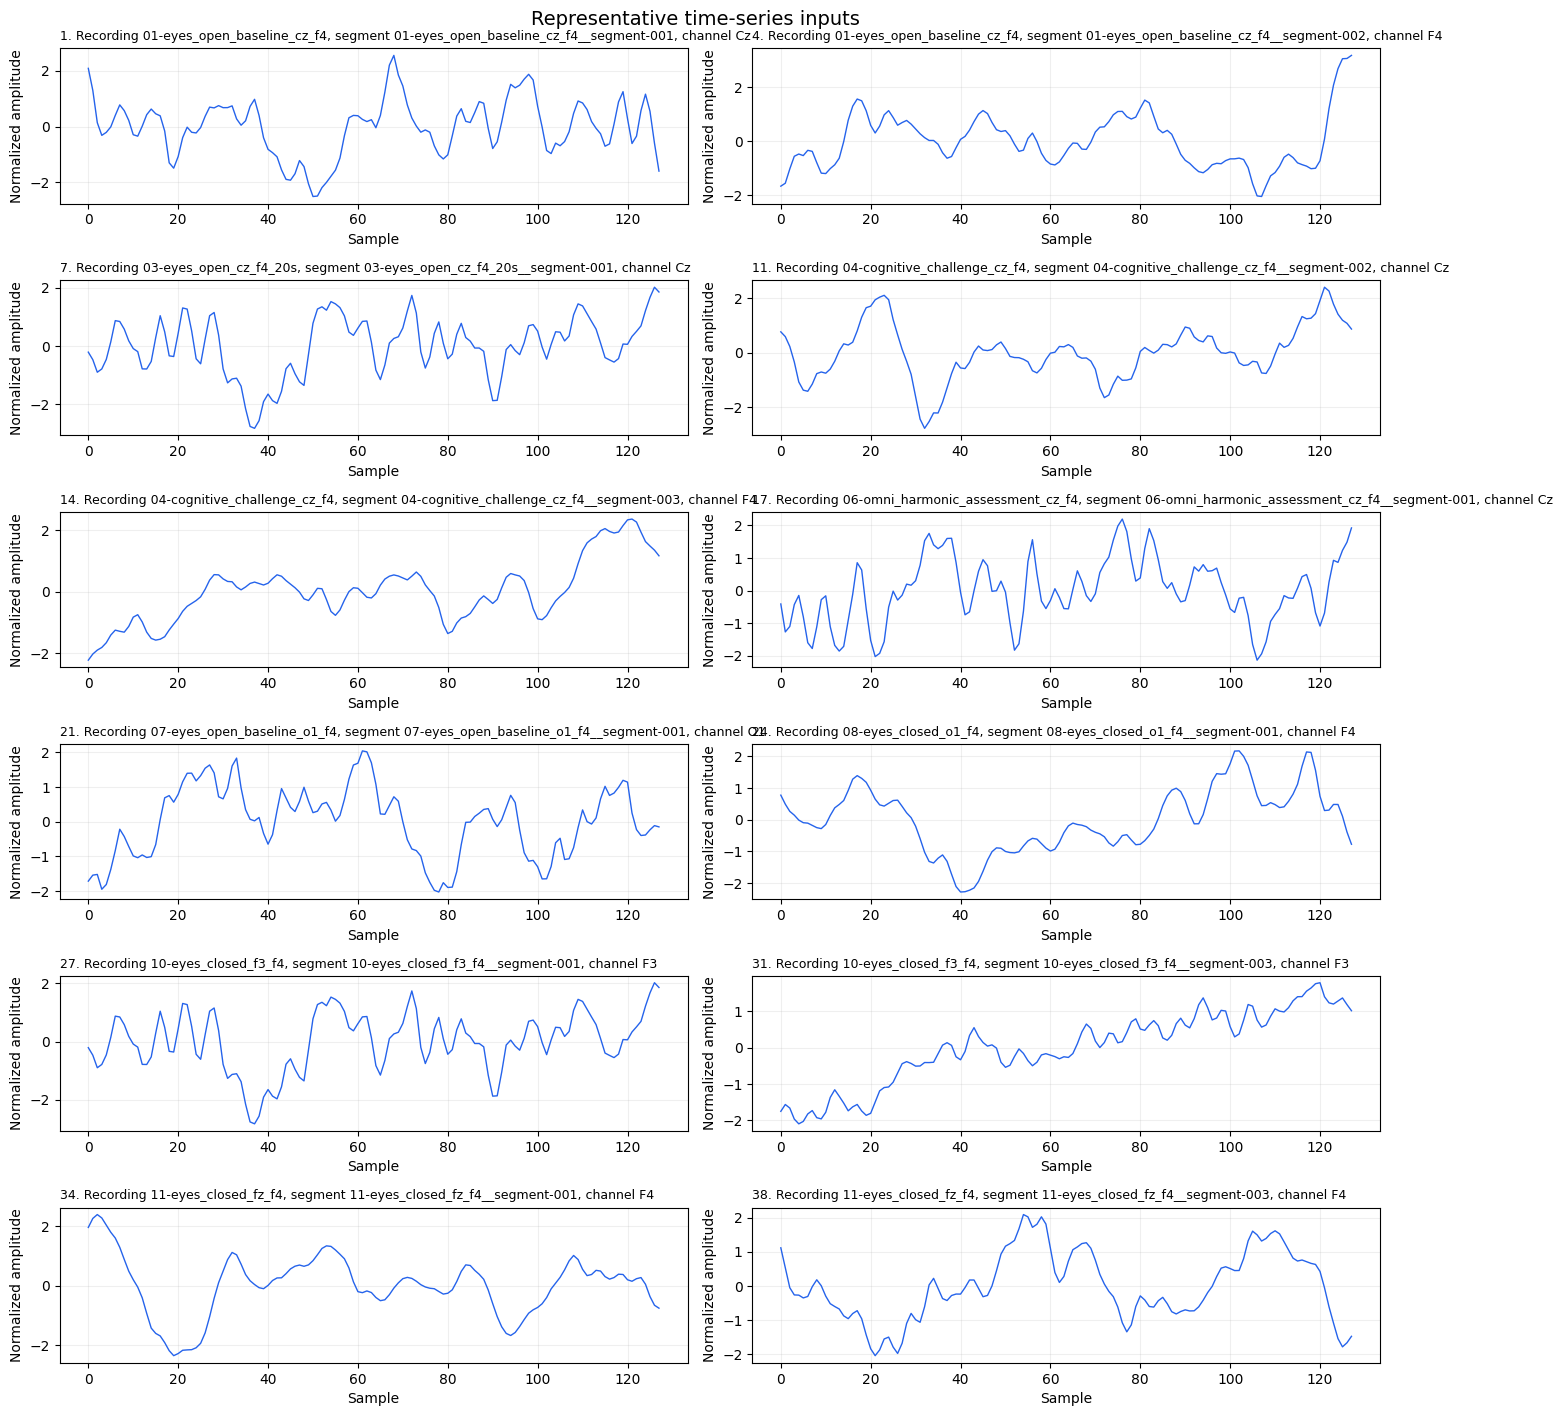

_Showing 12 evenly distributed series out of 38._

### Prompt

#### Signal-analysis instruction

```text
Integrate the patient's clinical history with the supplied EEG recordings. EEG is supporting evidence only and must not be treated as independently diagnostic.
```

#### Diagnostic task and clinical context

```text
Clinical profile: Referral: Evaluation of persistent attention and task-completion difficulty. Symptoms have lasted 250 months with 7 inattentive and 7 hyperactive/impulsive features; pattern: persistent. Functional settings: work, home. Informants: self: The patient reports persistent difficulty organizing work, tracking deadlines, and completing extended tasks. clinician: Clinical interview describes longstanding executive-function and sustained-attention difficulty across settings. Rating scales: synthetic_adult_self_report_scale 23.0/27.0 (elevated); synthetic_clinician_adhd_scale 21.0/27.0 (elevated). Alternative explanations: mild_sleep_onset_delay: May contribute to fatigue but does not fully explain the cross-setting symptom pattern..
Explain the EEG evidence, clinical evidence, and reasonable alternatives, then give the diagnosis, presentation, severity, and confidence.
```

Loading checkpoint and generating one response...


### Prediction

> EEG evidence: The mean recording-level theta-to-beta ratio is 29.0; the EEG findings are nonspecific and are treated only as supporting context. Clinical evidence: The synthetic profile contains 7 inattentive symptoms; these symptoms are likely due to the synthetic history. Alternative explanations: May contribute to fatigue but does not fully explain the cross-setting symptom pattern.; Discuss confounding variables: The synthetic history includes no relevant demographics or clinical covariates.; Discuss diagnostic overshadowing: The synthetic history includes no relevant diagnostic overshadowing.; Discuss functional impairment: The synthetic history includes no relevant functional impairment.; Discuss diagnostic overshadowing: The synthetic history includes no relevant diagnostic overshadowing.; Discuss treatment choice: The synthetic history includes no relevant treatment choice.EEG summary: The EEG findings are nonspecific and are treated only as supporting context. Additional clinical screening remains appropriate where indicated.

**Checkpoint:** `C:\Users\0ivan\OneDrive\Desktop\Coding\SmartHeart\checkpoints\google__gemma-3-1b-pt__fa56a704\sp\stage5_diagnostic_cot.pt`

In [4]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from src.curriculum import Curriculum
from src.data import SmartHeartDataset

PREDICTION_INDEX = 0  # @param {type:"integer"}
ADDITIONAL_INSTRUCTION = ""  # @param {type:"string"}
MAX_PLOTTED_SERIES = 12  # @param {type:"integer"}
PREDICTION_STAGE = "stage5_diagnostic_cot"
PREDICTION_RESULT = Path("tmp/single_prediction.json")

prediction_dataset = SmartHeartDataset(
    Path("dataset"),
    split="test",
    source_dataset=None if DATASET == "all" else DATASET,
    window_size=STAGE_WINDOW_SIZES[PREDICTION_STAGE],
)
prediction_stage = Curriculum(prediction_dataset, "<EOS>").get(PREDICTION_STAGE)
prediction_sample = prediction_stage[PREDICTION_INDEX]
post_prompt = str(prediction_sample["post_prompt"])
if ADDITIONAL_INSTRUCTION.strip():
    post_prompt += f"\nAdditional instruction: {ADDITIONAL_INSTRUCTION.strip()}"

display(Markdown(
    f"### Patient input\n\n"
    f"**Patient:** `{prediction_sample['patient_id']}`  \n"
    f"**Split:** `{prediction_sample['split']}`  \n"
    f"**Stage:** `{PREDICTION_STAGE}`  \n"
    f"**Available series:** `{len(prediction_sample['time_series'])}`"
))

series = prediction_sample["time_series"]
descriptions = prediction_sample["time_series_text"]
plot_count = min(max(1, MAX_PLOTTED_SERIES), len(series))
plot_indices = np.linspace(0, len(series) - 1, plot_count, dtype=int)
columns = 2 if plot_count > 1 else 1
rows = (plot_count + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(14, 2.4 * rows), squeeze=False)
for axis, series_index in zip(axes.flat, plot_indices):
    values = series[series_index].detach().cpu().numpy()
    axis.plot(values, color="#2563eb", linewidth=1.0)
    label = str(descriptions[series_index]).split(", contains", 1)[0]
    axis.set_title(f"{series_index + 1}. {label}", fontsize=9, loc="left")
    axis.set_xlabel("Sample")
    axis.set_ylabel("Normalized amplitude")
    axis.grid(alpha=0.2)
for axis in axes.flat[plot_count:]:
    axis.set_visible(False)
fig.suptitle("Representative time-series inputs", fontsize=14)
fig.tight_layout()
plt.show()
if plot_count < len(series):
    display(Markdown(
        f"_Showing {plot_count} evenly distributed series out of {len(series)}._"
    ))

display(Markdown(
    "### Prompt\n\n"
    "#### Signal-analysis instruction\n\n"
    f"```text\n{prediction_sample['pre_prompt']}\n```\n\n"
    "#### Diagnostic task and clinical context\n\n"
    f"```text\n{post_prompt}\n```"
))

PREDICTION_RESULT.parent.mkdir(parents=True, exist_ok=True)

command = [
    sys.executable, "-u", "-m", "src.main", "predict",
    "--source", DATASET,
    "--device", DEVICE,
    "--model-id", MODEL_ID,
    "--split", "test",
    "--stage", PREDICTION_STAGE,
    "--index", str(PREDICTION_INDEX),
    "--window-size", str(STAGE_WINDOW_SIZES[PREDICTION_STAGE]),
    "--output", str(PREDICTION_RESULT),
]
if ADDITIONAL_INSTRUCTION.strip():
    command.extend(["--prompt", ADDITIONAL_INSTRUCTION.strip()])

print("Loading checkpoint and generating one response...", flush=True)
process = subprocess.Popen(
    command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)
assert process.stdout is not None
console_output = "".join(process.stdout)
return_code = process.wait()
if return_code != 0:
    print(console_output)
    raise subprocess.CalledProcessError(return_code, command)
result = json.loads(PREDICTION_RESULT.read_text(encoding="utf-8"))
prediction_text = str(result["prediction"]).replace("\n", "\n> ")
display(Markdown(
    f"### Prediction\n\n> {prediction_text}\n\n"
    f"**Checkpoint:** `{result['checkpoint']}`"
))
